## Aula 6 — Dados e métricas

A Aula 5 percorreu o processo de desenvolvimento de uma RNA de ponta a ponta, sobre um conjunto sintético, balanceado e de duas dimensões. Duas etapas daquele processo foram tratadas de forma sumária, com a promessa de retomá-las: a preparação dos dados e a escolha da métrica.

Esta aula retoma as duas, e o faz sobre um conjunto real em que as simplificações da Aula 5 deixam de valer. O conjunto tem 284.807 transações de cartão de crédito, das quais 492 são fraudulentas — uma classe positiva que representa 0,17% do total. Nesse regime, a exatidão deixa de ser uma métrica informativa, e a própria função de custo precisa ser modificada.

Os objetivos são:

- estabelecer os critérios para dividir os dados em treinamento, validação e teste;
- apresentar a normalização das entradas e a razão pela qual ela acelera o treinamento;
- apresentar as métricas usuais de classificação binária, com as situações em que cada uma falha;
- treinar uma RNA sobre um conjunto fortemente desbalanceado e corrigir a função de custo para esse desbalanceamento.

---

## Bibliotecas

In [1]:
import os

from tensorflow.python.keras.callbacks import EarlyStopping

# O backend precisa ser definido ANTES de importar o keras.
os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, auc

print("Keras   :", keras.__version__)
print("Backend :", keras.backend.backend())

I0000 00:00:1789581368.860795    2002 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Keras   : 3.15.1
Backend : tensorflow


---

## O conjunto de dados

O conjunto é o *Credit Card Fraud Detection*, com transações feitas por portadores europeus em dois dias de setembro de 2013 (Andrea Dal Pozzolo, Olivier Caelen, Reid A. Johnson e Gianluca Bontempi, *Calibrating Probability with Undersampling for Unbalanced Classification*, IEEE Symposium Series on Computational Intelligence, 2015).

São 31 colunas. As colunas `V1` a `V28` são componentes principais obtidas por PCA sobre as variáveis originais, que não foram divulgadas por sigilo. `Time` é o número de segundos decorridos desde a primeira transação do conjunto, `Amount` é o valor da transação e `Class` vale 1 para fraude e 0 caso contrário.

Que as entradas sejam componentes de PCA tem uma consequência prática: elas já vêm descorrelacionadas e centradas, e não há como interpretar nenhuma delas individualmente. Só `Time` e `Amount` preservam significado.

Para ler arquivos CSV a ferramenta usual é o **pandas**, que oferece um conjunto amplo de funções para manipular dados estruturados em tabela.

In [2]:
URL = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

dados_brutos = pd.read_csv(URL)

print("dimensões:", dados_brutos.shape)
dados_brutos.head()

dimensões: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
dados_brutos[["Time", "V1", "V2", "V3", "V26", "V27", "V28", "Amount", "Class"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V26,284807.0,1.686100e-15,0.482227,-2.604551,-0.326984,-0.052139,0.240952,3.517346
V27,284807.0,-3.661401e-16,0.403632,-22.565679,-0.070840,0.001342,0.091045,31.612198
V28,284807.0,-1.227452e-16,0.330083,-15.430084,-0.052960,0.011244,0.078280,33.847808
Amount,284807.0,8.834962e+01,250.120109,0.000000,5.600000,22.000000,77.165000,25691.160000
Class,284807.0,1.727486e-03,0.041527,0.000000,0.000000,0.000000,0.000000,1.000000


A tabela acima já indica o que precisa ser corrigido antes do treinamento. As colunas `V1` a `V28`, por serem componentes de PCA, têm média praticamente nula e desvio padrão de ordem unitária. `Time` e `Amount` não: a primeira vai a 172.792 e a segunda a 25.691. Duas colunas com valores dessa ordem convivendo com vinte e oito de ordem unitária é exatamente a situação que a normalização resolve.

### Verificação do desbalanceamento

Antes de qualquer decisão sobre a rede, é preciso saber como as classes se distribuem. Essa contagem condiciona a escolha da métrica, a divisão dos dados e a função de custo.

In [4]:
neg, pos = np.bincount(dados_brutos["Class"])
total = neg + pos

print(f"total     : {total}")
print(f"positivos : {pos} ({100 * pos / total:.3f}% do total)")
print(f"negativos : {neg}")
print(f"proporção : 1 fraude para cada {neg / pos:.0f} transações legítimas")

total     : 284807
positivos : 492 (0.173% do total)
negativos : 284315
proporção : 1 fraude para cada 578 transações legítimas


Uma fraude para cada quinhentas e setenta e oito transações legítimas.

### Limpeza inicial

Duas colunas exigem tratamento.

`Time` é descartada. Ela conta segundos desde a primeira transação do conjunto, uma grandeza que não se transporta para dados novos: em produção, uma transação não tem um "segundo desde o início da coleta". Usá-la como entrada equivale a informar à rede a posição do exemplo dentro deste arquivo específico.

`Amount` é mantida, mas transformada. Os valores vão de zero a mais de vinte e cinco mil, e a distribuição é fortemente assimétrica — a maioria das transações é de valor baixo e algumas poucas são de valor muito alto. Aplicar o logaritmo comprime essa cauda e aproxima a distribuição de uma forma mais simétrica. Como existem transações de valor zero, soma-se uma constante pequena antes do logaritmo para evitar o logaritmo de zero.

In [5]:
dados = dados_brutos.copy()

dados.pop("Time")

eps = 0.001                                        # evita log(0)
dados["LogAmount"] = np.log(dados.pop("Amount") + eps)

print("dimensões:", dados.shape)
dados.head()

dimensões: (284807, 30)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Class,LogAmount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,5.008105
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,0.989913
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,5.936641
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,4.816249
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,4.248367


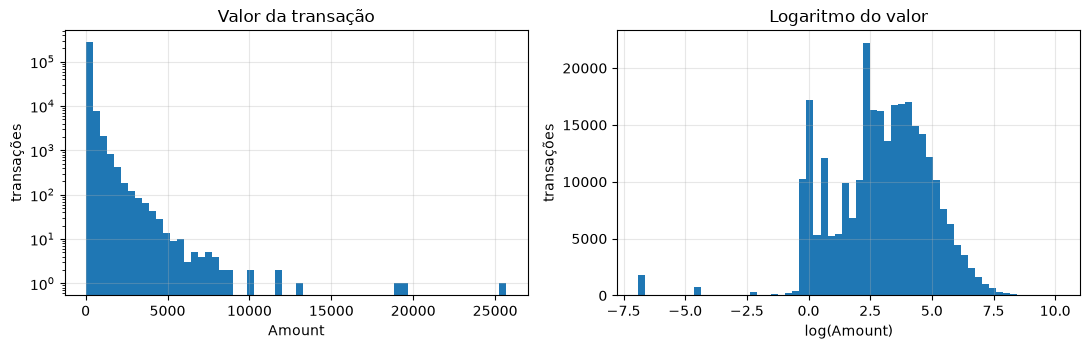

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))

ax1.hist(dados_brutos["Amount"], bins=60, color="tab:blue")
ax1.set_xlabel("Amount"); ax1.set_ylabel("transações")
ax1.set_title("Valor da transação")
ax1.set_yscale("log"); ax1.grid(alpha=.3)

ax2.hist(dados["LogAmount"], bins=60, color="tab:blue")
ax2.set_xlabel("log(Amount)"); ax2.set_ylabel("transações")
ax2.set_title("Logaritmo do valor")
ax2.grid(alpha=.3)

plt.tight_layout(); plt.show()

---

## Divisão dos dados

A Aula 5 apresentou a função de cada subconjunto e a razão de existir um conjunto de validação separado do de teste. O que fica em aberto é quanto colocar em cada um e como fazer o corte.

### Princípios

Seis critérios orientam a divisão.

1. O tipo de dado do conjunto de treinamento deve ser o mesmo dos conjuntos de validação e teste.
2. Validação e teste devem refletir os dados que se espera encontrar quando o sistema estiver em operação.
3. Validação e teste devem conter os casos considerados importantes, aqueles em que se exige bom desempenho.
4. O conjunto de validação precisa ser grande o suficiente para distinguir entre os modelos que estão sendo comparados.
5. O conjunto de teste precisa ser grande o suficiente para dar confiança no resultado obtido.
6. A divisão numérica segue regras de proporção.

Os critérios 4 e 5 governam o tamanho. Como o erro padrão de uma proporção decresce com a raiz do número de exemplos, há um ponto a partir do qual acrescentar exemplos à avaliação deixa de compensar, e é melhor destiná-los ao treinamento. Daí as proporções usuais:

| Número de exemplos | Treinamento | Validação | Teste |
|---|---|---|---|
| 100 a 10.000, sem conjunto de teste | 80% | 20% | — |
| 100 a 10.000, com os três conjuntos | 70% | 15% | 15% |
| 10.000 a 1.000.000 | interpolação entre as linhas vizinhas | | |
| acima de 1.000.000 | 98% | 1% | 1% |

Com um milhão de exemplos, 1% já são dez mil exemplos de teste, suficientes para um erro padrão da ordem de meio ponto percentual. Separar duzentos mil não traria ganho de precisão que justificasse a perda no treinamento.

Nossos 284.807 exemplos ficam na faixa intermediária. A divisão adotada é 70% / 15% / 15%.

### Estratificação

O critério 1 tem uma consequência que passa despercebida com facilidade. Cortar o conjunto ao acaso preserva a proporção entre as classes apenas em média, não em cada divisão específica. Com 26% de positivos isso produziria uma variação pequena; com 0,17%, a variação é grave.

A Aula 5 já tratou disso: a função `divide_conjuntos` lá construída separava os índices por classe antes de cortar, justamente para preservar a proporção. Aqui usamos `train_test_split` do scikit-learn, cujo argumento `stratify` faz o mesmo.

O argumento `random_state` fixa a divisão. Sem ele, cada execução do notebook produz uma partição diferente, e passa a ser impossível distinguir uma melhora real do modelo de uma variação de sorteio.

In [7]:
# Separa as saídas das entradas
y = dados.pop("Class").to_numpy()
X = dados.to_numpy(dtype="float32")

# 70% treinamento, 15% validação, 15% teste
X_treino, X_resto, y_treino, y_resto = train_test_split(
    X, y, test_size=0.30, random_state=0, stratify=y)

X_val, X_teste, y_val, y_teste = train_test_split(
    X_resto, y_resto, test_size=0.50, random_state=0, stratify=y_resto)

for nome, Xc, yc in [("treino", X_treino, y_treino),
                     ("validação", X_val, y_val),
                     ("teste", X_teste, y_teste)]:
    print(f"{nome:<10} {Xc.shape}   positivos: {yc.sum():>3}   "
          f"({100 * yc.mean():.3f}%)")

treino     (199364, 29)   positivos: 344   (0.173%)
validação  (42721, 29)   positivos:  74   (0.173%)
teste      (42722, 29)   positivos:  74   (0.173%)


As três proporções ficaram iguais até a terceira casa decimal, e cada subconjunto tem positivos suficientes para que as métricas sejam calculáveis.

Sem estratificação, algumas divisões produziriam conjuntos de validação com pouquíssimos positivos. O treinamento rodaria normalmente, e a revocação de validação seria zero ou indefinida — não por defeito do modelo, mas por defeito do corte.

Convém também comparar com a alternativa que aparece em muitos materiais, o corte por fatiamento direto do vetor:

    x_val   = x[:2000, :]
    x_teste = x[2000:4000, :]
    x_treino = x[4000:, :]

Isso só é correto se o conjunto já estiver embaralhado e as classes distribuídas ao acaso. Neste conjunto os exemplos estão em ordem cronológica, e fraudes tendem a ocorrer em rajadas. Fatiar sem embaralhar concentraria rajadas inteiras em um único subconjunto.

---

## Normalização das entradas

Não é adequado alimentar uma RNA com entradas de valores absolutos grandes, nem com entradas heterogêneas entre si — algumas componentes variando entre 0 e 1 e outras entre 100 e 1000.

Dois efeitos decorrem disso. O primeiro é a saturação das funções de ativação: entradas grandes produzem estados grandes, que levam sigmoides e tangentes hiperbólicas às regiões planas, onde a derivada é próxima de zero. A retropropagação multiplica essas derivadas ao longo das camadas, e o gradiente das primeiras camadas desaparece. O caso oposto, de estados que crescem camada a camada, produz gradientes que explodem.

O segundo efeito é geométrico. Quando as componentes da entrada têm escalas muito diferentes, as curvas de nível da função de custo ficam alongadas em algumas direções e comprimidas em outras. O gradiente aponta na direção de maior inclinação, que nesse caso não aponta para o mínimo, e a trajetória do gradiente descendente ziguezagueia. Com as escalas equalizadas, as curvas de nível ficam aproximadamente circulares e o gradiente aponta direto para o mínimo.

Para evitar os dois efeitos, as entradas devem ter valores pequenos e faixas de variação semelhantes entre si.

### As operações

Para cada componente $j$ das entradas, calcula-se a média sobre os exemplos de treinamento,

$$\bar{x}_j = \frac{1}{m}\sum_{i=1}^{m} x_j^{(i)}$$

o desvio padrão,

$$\sigma_j = \sqrt{\frac{1}{m}\sum_{i=1}^{m}\left(x_j^{(i)} - \bar{x}_j\right)^2}$$

e a entrada normalizada,

$$\tilde{x}_j^{(i)} = \frac{x_j^{(i)} - \bar{x}_j}{\sigma_j}$$

A normalização é feita componente a componente, de forma independente, e a divisão é pelo **desvio padrão**, não pela variância. Depois da transformação cada componente tem média zero e desvio padrão um sobre o conjunto de treinamento.

### As estatísticas vêm apenas do treinamento

As médias e os desvios são calculados **somente** sobre os dados de treinamento, e depois aplicados aos conjuntos de validação e teste. Nunca se usam os dados de validação ou teste para calcular os parâmetros da normalização.

A razão é a mesma que justifica a existência do conjunto de teste. Se a média fosse calculada sobre o conjunto inteiro, cada exemplo de teste teria contribuído, ainda que pouco, para a transformação aplicada aos dados de treinamento, e o conjunto de teste deixaria de ser um conjunto nunca visto.

O mesmo vale em produção: os vetores de médias e desvios fazem parte do pré-processamento e precisam ser guardados junto com o modelo, como o valor de `escala` na Aula 5.

Aqui as saídas não são normalizadas, porque em classificação binária a saída já é 0 ou 1. Em problemas de ajuste de função, as saídas costumam receber o mesmo tratamento das entradas.

In [8]:
media  = X_treino.mean(axis=0)     # calculadas somente no treinamento
desvio = X_treino.std(axis=0)

X_treino = (X_treino - media) / desvio
X_val    = (X_val    - media) / desvio
X_teste  = (X_teste  - media) / desvio

print(f"treino     média [{X_treino.mean(axis=0).min():+.2e}, {X_treino.mean(axis=0).max():+.2e}]   "
      f"desvio [{X_treino.std(axis=0).min():.3f}, {X_treino.std(axis=0).max():.3f}]")
print(f"validação  média [{X_val.mean(axis=0).min():+.3f}, {X_val.mean(axis=0).max():+.3f}]   "
      f"desvio [{X_val.std(axis=0).min():.3f}, {X_val.std(axis=0).max():.3f}]")
print(f"teste      média [{X_teste.mean(axis=0).min():+.3f}, {X_teste.mean(axis=0).max():+.3f}]   "
      f"desvio [{X_teste.std(axis=0).min():.3f}, {X_teste.std(axis=0).max():.3f}]")

treino     média [-2.26e-05, +5.65e-08]   desvio [1.000, 1.000]
validação  média [-0.010, +0.007]   desvio [0.956, 1.098]
teste      média [-0.009, +0.011]   desvio [0.954, 1.020]


O conjunto de treinamento fica com média zero e desvio um por construção. Os conjuntos de validação e teste não ficam exatamente assim, e é esse o comportamento correto: se ficassem, seria porque as estatísticas deles foram usadas.

### Distribuição das entradas por classe

Vale comparar como as duas classes se distribuem em algumas componentes. Duas perguntas orientam a leitura: as distribuições fazem sentido, e é possível distinguir uma da outra.

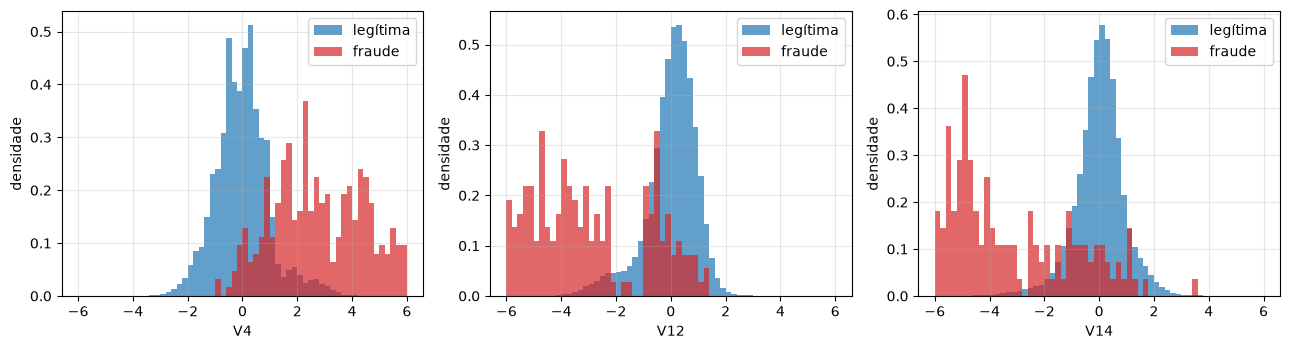

In [9]:
componentes = ["V4", "V12", "V14"]
indices = [dados.columns.get_loc(c) for c in componentes]

fig, eixos = plt.subplots(1, 3, figsize=(13, 3.6))

for ax, nome, j in zip(eixos, componentes, indices):
    ax.hist(X_treino[y_treino == 0, j], bins=60, range=(-6, 6), density=True,
            color="tab:blue", alpha=.7, label="legítima")
    ax.hist(X_treino[y_treino == 1, j], bins=60, range=(-6, 6), density=True,
            color="tab:red", alpha=.7, label="fraude")
    ax.set_xlabel(nome); ax.set_ylabel("densidade")
    ax.legend(); ax.grid(alpha=.3)

plt.tight_layout(); plt.show()

In [10]:
m_treino = len(y_treino)
n1 = int(y_treino.sum())
n0 = m_treino - n1

p0 = m_treino / (2 * n0)
p1 = m_treino / (2 * n1)

print(f"m = {m_treino}   n0 = {n0}   n1 = {n1}")
print(f"p0 = {p0:.4f}")
print(f"p1 = {p1:.4f}")

# Conferência com o scikit-learn (argumentos nomeados são obrigatórios)
pesos_sk = class_weight.compute_class_weight(
    class_weight="balanced", classes=np.unique(y_treino), y=y_treino)
print("\nscikit-learn:", np.round(pesos_sk, 4))

PESOS_CLASSES = {0: p0, 1: p1}

m = 199364   n0 = 199020   n1 = 344
p0 = 0.5009
p1 = 289.7733

scikit-learn: [  0.5009 289.7733]


In [36]:
import model_optimizer as mo

model_searcher = mo.ModelSearcher(X_treino, y_treino, X_val, y_val,
                                  model_comparator='val_recall')
best_model, best_history, best_accuracy = model_searcher.fit(
    model_factory=mo.DefaultModelFactory(
        hidden_factory=mo.DefaultLayerFactory(activation='silu'),
        model_compiler=mo.DefaultModelCompiler(loss='binary_crossentropy', metrics=['accuracy', 'recall'])
    ),
    model_fitter=mo.DefaultModelFitter(epochs=200, batch_size=10000, class_weight=PESOS_CLASSES),
    layer_init=(54,42,16)
)

Trying model with hidden layers: [54, 42, 16]


I0000 00:00:1789664239.007106    2078 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1086288__.15
I0000 00:00:1789664241.995591    2079 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1086288__.15


New best model found with history: {'accuracy': 0.9965590834617615, 'loss': 0.008856197819113731, 'recall': 1.0, 'val_accuracy': 0.9955057501792908, 'val_loss': 0.022398963570594788, 'val_recall': 0.8513513803482056}
Trying model with hidden layers: [81, 42, 16]


I0000 00:00:1789664266.263100    2077 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1106465__.15
I0000 00:00:1789664267.866603    2078 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1106465__.15


Trying model with hidden layers: [122, 42, 16]


...

I0000 00:00:1789664436.166588    2076 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1216923__.19
I0000 00:00:1789664437.955514  441508 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_18', 476 bytes spill stores, 340 bytes spill loads

I0000 00:00:1789664440.405251    2079 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1216923__.19
I0000 00:00:1789664441.942312  441551 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_18', 516 bytes spill stores, 364 bytes spill loads



Trying model with hidden layers: [183, 122, 54, 42, 16]


I0000 00:00:1789664460.495650    2079 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1227577__.19
I0000 00:00:1789664461.348478  444880 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_18', 384 bytes spill stores, 384 bytes spill loads

I0000 00:00:1789664461.603470  444879 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_18', 392 bytes spill stores, 352 bytes spill loads

I0000 00:00:1789664464.902620    2077 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1227577__.19
I0000 00:00:1789664465.764686  444923 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_18', 388 bytes spill stores, 388 bytes spill loads

I0000 00:00:1789664466.031632  444920 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local m

Trying model with hidden layers: [275, 122, 54, 42, 16]


I0000 00:00:1789664476.399996    2076 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1235880__.19
I0000 00:00:1789664478.181874  447312 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_18', 384 bytes spill stores, 384 bytes spill loads

I0000 00:00:1789664478.468088  447311 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_18', 428 bytes spill stores, 348 bytes spill loads

I0000 00:00:1789664481.109068    2078 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1235880__.19
I0000 00:00:1789664482.345861  447357 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_18', 388 bytes spill stores, 388 bytes spill loads

I0000 00:00:1789664482.715190  447360 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local m

best recall: [122, 54, 42, 16]


Model: "sequential_51"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_161 (Dense)               │ (199364, 122)          │         3,660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_162 (Dense)               │ (199364, 54)           │         6,642 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_163 (Dense)               │ (199364, 42)           │         2,310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_164 (Dense)               │ (199364, 16)           │           688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_165 (Dense)               │ (199364, 1)            │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,636 (104.05 KB)

 Trainable params: 13,317 (52.02 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,319 (52.03 KB)

None


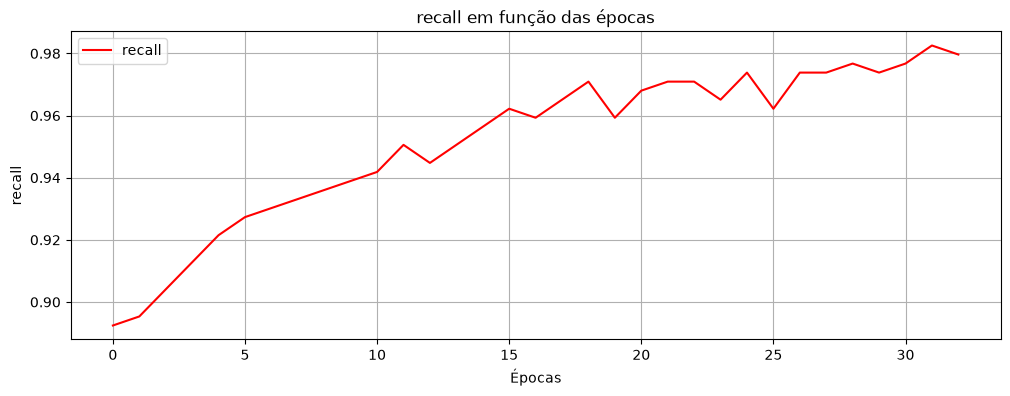

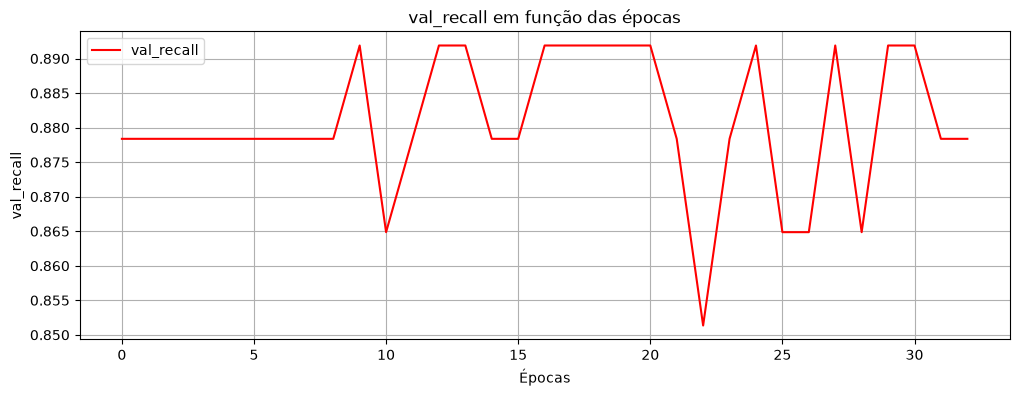

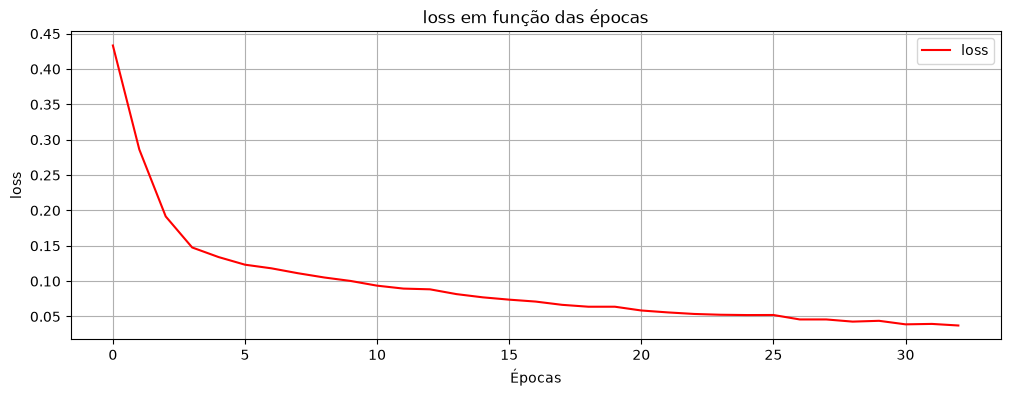

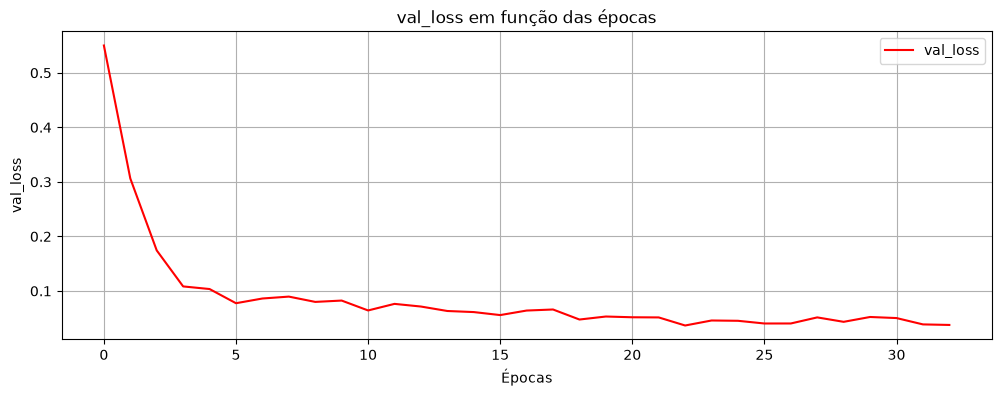

In [37]:
print('best recall:', best_accuracy)
print(best_model.summary())
for label in ['recall', 'val_recall', 'loss', 'val_loss']:
    plt.figure(figsize=(12, 4))
    plt.plot(best_history.history[label], 'r', label=label)
    plt.title(f'{label} em função das épocas')
    plt.xlabel('Épocas')
    plt.ylabel(label)
    plt.legend()
    plt.grid()
    plt.show()

I0000 00:00:1789664702.516182    2078 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


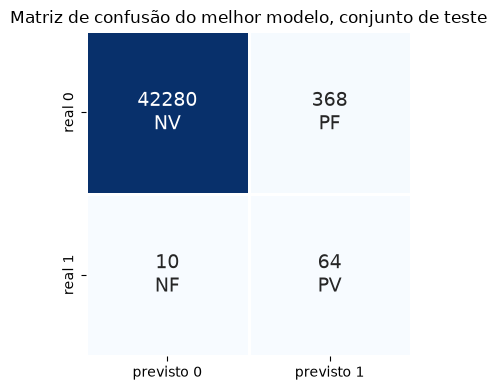

matriz de confusão:
 [[42280   368]
 [   10    64]]


In [38]:
prob_best = best_model.predict(X_teste, verbose=0).ravel()
classe_best = (prob_best >= 0.5).astype(int)
MC_best = confusion_matrix(y_teste, classe_best)

rotulos = np.array([["NV", "PF"], ["NF", "PV"]])
anotacoes = np.array([
    [f"{MC_best[i, j]}\n{rotulos[i, j]}" for j in range(2)]
    for i in range(2)
])

plt.figure(figsize=(4.8, 4.0))
sns.heatmap(
    MC_best, annot=anotacoes, fmt="", cmap="Blues", cbar=False, square=True,
    annot_kws={"size": 14}, linewidths=1, linecolor="white",
    xticklabels=["previsto 0", "previsto 1"],
    yticklabels=["real 0", "real 1"]
)
plt.title("Matriz de confusão do melhor modelo, conjunto de teste")
plt.tight_layout()
plt.show()

print("matriz de confusão:\n", MC_best)